In [8]:
import os
os.makedirs('results', exist_ok=True)

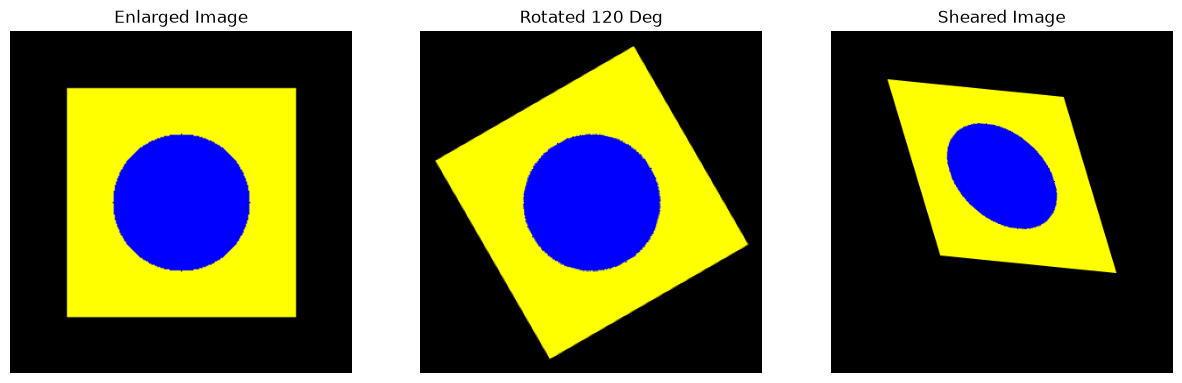

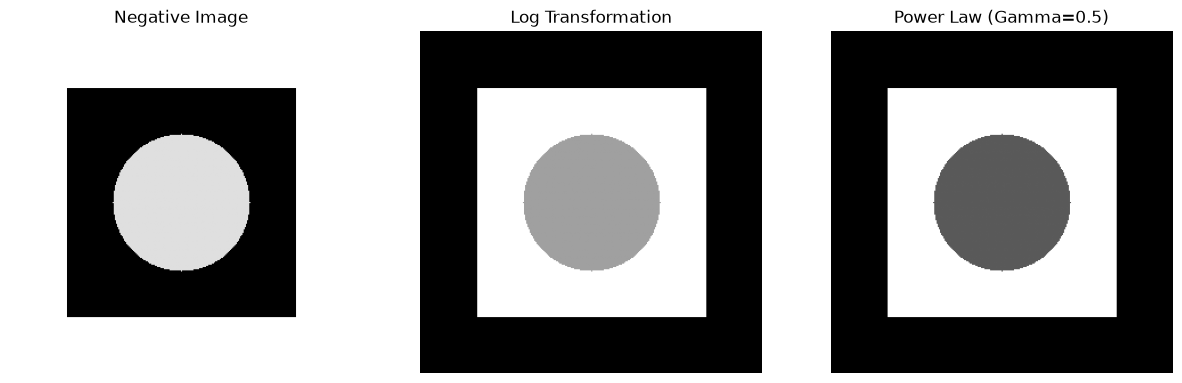

In [7]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.rectangle(img, (50, 50), (250, 250), (0, 255, 255), -1)
cv2.circle(img, (150, 150), 60, (255, 0, 0), -1)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

height, width = img.shape[:2]
enlarged_img = cv2.resize(img, (width * 2, height * 2), interpolation=cv2.INTER_CUBIC)

center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))

shear_matrix = np.float32([[1, 0.3, 0], [0.1, 1, 0]])
sheared_img = cv2.warpAffine(img, shear_matrix, (int(width * 1.3), int(height * 1.3)))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(enlarged_img, cv2.COLOR_BGR2RGB))
plt.title('Enlarged Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
plt.title('Rotated 120 Deg')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
plt.title('Sheared Image')
plt.axis('off')
plt.show()

negative_img = 255 - gray_img

c = 255 / np.log(1 + np.max(gray_img))
log_img = c * np.log(1 + gray_img.astype(np.float32))
log_img = np.array(log_img, dtype=np.uint8)

gamma = 0.5
gamma_img = np.array(255 * (gray_img / 255.0) ** gamma, dtype=np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(negative_img, cmap='gray')
plt.title('Negative Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformation')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_img, cmap='gray')
plt.title(f'Power Law (Gamma={gamma})')
plt.axis('off')
plt.show()